Some code was generated by Gemini, ideas are my own.

Video for inspiration:
https://www.youtube.com/watch?v=ccIl0clxJpE


**Ideas for later**
- Sliders for alpha, beta, gamma, and delta?
- Monte Carlo Simulation (https://www.youtube.com/shorts/_eJVBmi4jwg)



# Background:
![](img/wiki.png)
The Lotka–Volterra predator-prey model makes a number of assumptions about the environment and biology of the predator and prey populations:

1. The prey population finds ample food at all times.
2. The food supply of the predator population depends entirely on the size of the prey population.
3. The rate of change of population is proportional to its size.
4. During the process, the environment does not change in favour of one species, and genetic adaptation is inconsequential.
5. Predators have limitless appetite.
6. Both populations can be described by a single variable. This amounts to assuming that the populations do not have a spatial or age distribution that contributes to the dynamics.
From: https://en.wikipedia.org/wiki/Lotka%E2%80%93Volterra_equations

# Setting up ODEs

- When solving ODEs, we want to first determine what the initial point where dx/dt = 0. 
  - This is also referred to as nullclines. Nullclines are curves in a phase plane where the rate of change of a specific variable in a dynamical system is zero. (from browser GPT)
  - However, for a Lotka-Volterra model, there are fluctuations that we would anticipate where:
  - ![](img/nullcline-conditions.png)

In [14]:
import polars as pl
import numpy as np


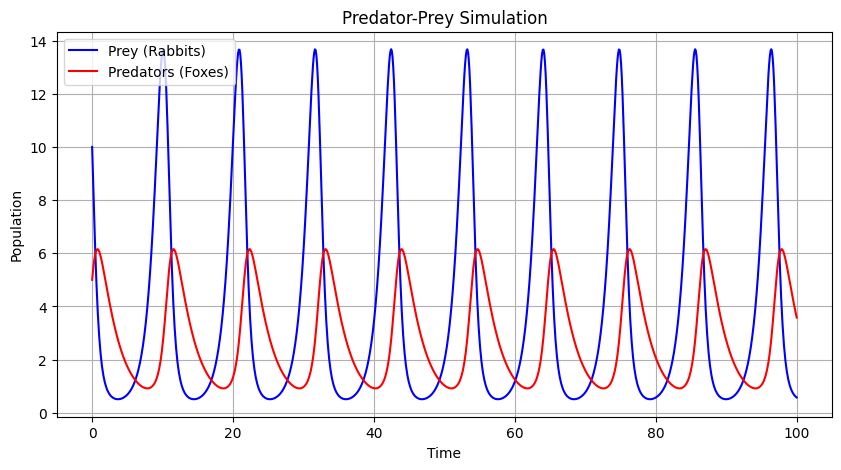

In [15]:
'''
This is a rough draft of printing out a MVP of a Predator-Prey model, but we just imported the ODE solver, which would be nice to know under the hood... 
which is explored in later blocks of code
'''

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

#set up equation
def lotka_volterra(z, t, a, b, c, d):
    x, y = z
    dxdt = a*x - b*x*y
    dydt = d*x*y - c*y
    return [dxdt, dydt]

# Set parameters and initial conditions
# a: prey growth, b: predation rate, c: predator death, d: predator growth
params = (1.1, 0.4, 0.4, 0.1) 
initial_state = [10, 5]  # 10 rabbits, 5 foxes

# Create a time grid (0 to 100 units of time)
# np.linspace makes an array of evenly spaced numbers over a specified interval
t = np.linspace(0, 100, 1000)

# Solve the ODE
solution = odeint(lotka_volterra, initial_state, t, args=params)
#need to transpose bc odeint returns a 
prey, predators = solution.T

# Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(t, prey, label='Prey (Rabbits)', color='blue')
plt.plot(t, predators, label='Predators (Foxes)', color='red')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Predator-Prey Simulation')
plt.legend()
plt.grid(True)
plt.show()

As more rabbits are being eaten, and the foxes continue to grow, we see the prey decreasing, until it gets to a point where there's only so much prey that can be sustained. 

Text(0.5, 1.0, 'Phase Portrait')

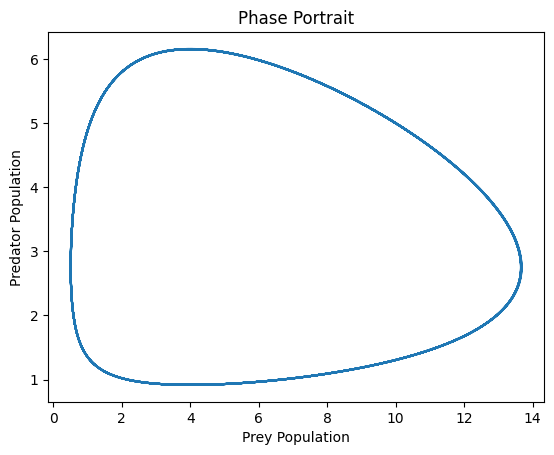

In [16]:
#this is a phase portrait, which shows that the system is fully contained, and the pred/prey runs in a constant cycle of growth and decline accordingly.
plt.plot(prey, predators)
plt.xlabel('Prey Population')
plt.ylabel('Predator Population')
plt.title('Phase Portrait')

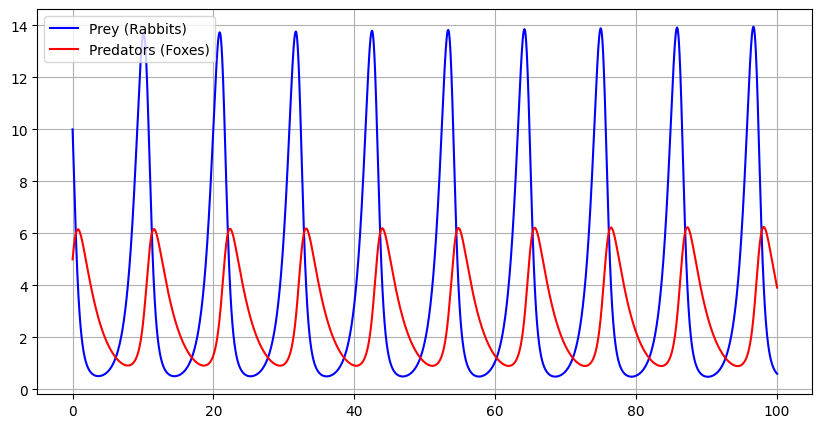

In [17]:
#raw implementation with first order 
import numpy as np
import matplotlib.pyplot as plt

# Parameters (adjusted to match the visual scale of your image)
a, b, c, d = 1.1, 0.4, 0.4, 0.1
# dt = 0.001  # Very small step to reduce numerical drift - making it too small just wastes computation time, but too big makes the system very rough and uninterpretable
dt = 0.001
t_final = 100 #this creates 100,000 time steps for prey
steps = int(t_final / dt)

prey = np.zeros(steps)
pred = np.zeros(steps)
t = np.linspace(0, t_final, steps)

# Initial population conditions
prey[0] = 10
pred[0] = 5

#LV pred-prey equation implementation
#
for i in range(1, steps):
    # Forward Euler logic
    dxdt = a * prey[i-1] - b * prey[i-1] * pred[i-1]
    dydt = d * prey[i-1] * pred[i-1] - c * pred[i-1]
    
    prey[i] = prey[i-1] + (dxdt * dt)
    pred[i] = pred[i-1] + (dydt * dt)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(t, prey, label='Prey (Rabbits)', color='blue')
plt.plot(t, pred, label='Predators (Foxes)', color='red')
plt.grid(True)
plt.legend()
plt.show()

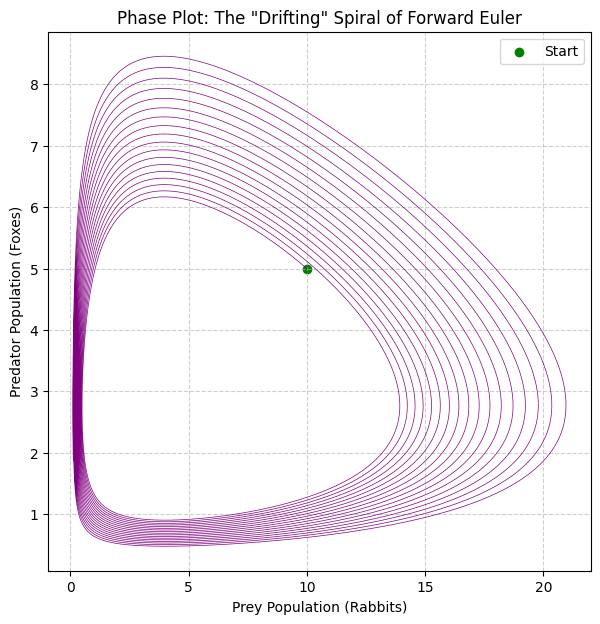

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
a, b, c, d = 1.1, 0.4, 0.4, 0.1
dt = 0.01 
t_final = 200 # Increased time to see the drift clearly
steps = int(t_final / dt)

prey = np.zeros(steps)
pred = np.zeros(steps)

# Initial conditions
prey[0] = 10
pred[0] = 5

# Forward Euler Loop
for i in range(1, steps):
    dxdt = a * prey[i-1] - b * prey[i-1] * pred[i-1]
    dydt = d * prey[i-1] * pred[i-1] - c * pred[i-1]
    
    prey[i] = prey[i-1] + (dxdt * dt)
    pred[i] = pred[i-1] + (dydt * dt)

# Phase Plot
plt.figure(figsize=(7, 7))
plt.plot(prey, pred, color='purple', lw=0.5)
plt.xlabel('Prey Population (Rabbits)')
plt.ylabel('Predator Population (Foxes)')
plt.title('Phase Plot: The "Drifting" Spiral of Forward Euler')
plt.grid(True, linestyle='--', alpha=0.6)

# Mark the start point
plt.scatter(prey[0], pred[0], color='green', label='Start')
plt.legend()

plt.show()

# Backward Euler Method

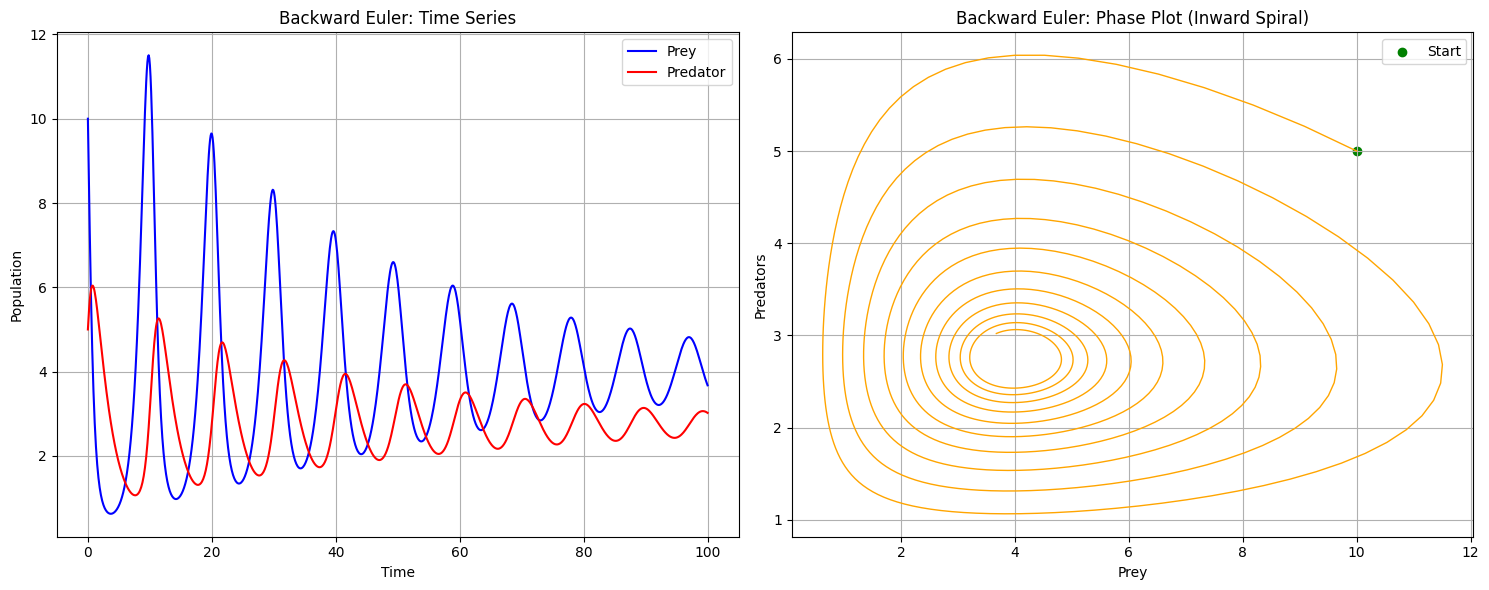

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# 1. Model Parameters
a, b, c, d = 1.1, 0.4, 0.4, 0.1
dt = 0.1 
t_final = 100
steps = int(t_final / dt)

def f(z):
    x, y = z
    return np.array([a*x - b*x*y, d*x*y - c*y])

# 2. Storage
z_back = np.zeros((steps, 2))
z_back[0] = [10.0, 5.0]
t = np.linspace(0, t_final, steps)

# 3. Backward Euler Loop (Implicit)
for i in range(1, steps):
    z_prev = z_back[i-1]
    
    # Implicit equation: z_new = z_prev + f(z_new) * dt
    def objective(z_new):
        return z_new - z_prev - f(z_new) * dt
    
    # Solve for z_new
    z_back[i] = fsolve(objective, z_prev)

prey, pred = z_back.T

# 4. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Time Series
ax1.plot(t, prey, label='Prey', color='blue')
ax1.plot(t, pred, label='Predator', color='red')
ax1.set_title('Backward Euler: Time Series')
ax1.set_xlabel('Time')
ax1.set_ylabel('Population')
ax1.legend()
ax1.grid(True)

# Subplot 2: Phase Plot
ax2.plot(prey, pred, color='orange', lw=1)
ax2.scatter(10, 5, color='green', label='Start')
ax2.set_title('Backward Euler: Phase Plot (Inward Spiral)')
ax2.set_xlabel('Prey')
ax2.set_ylabel('Predators')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

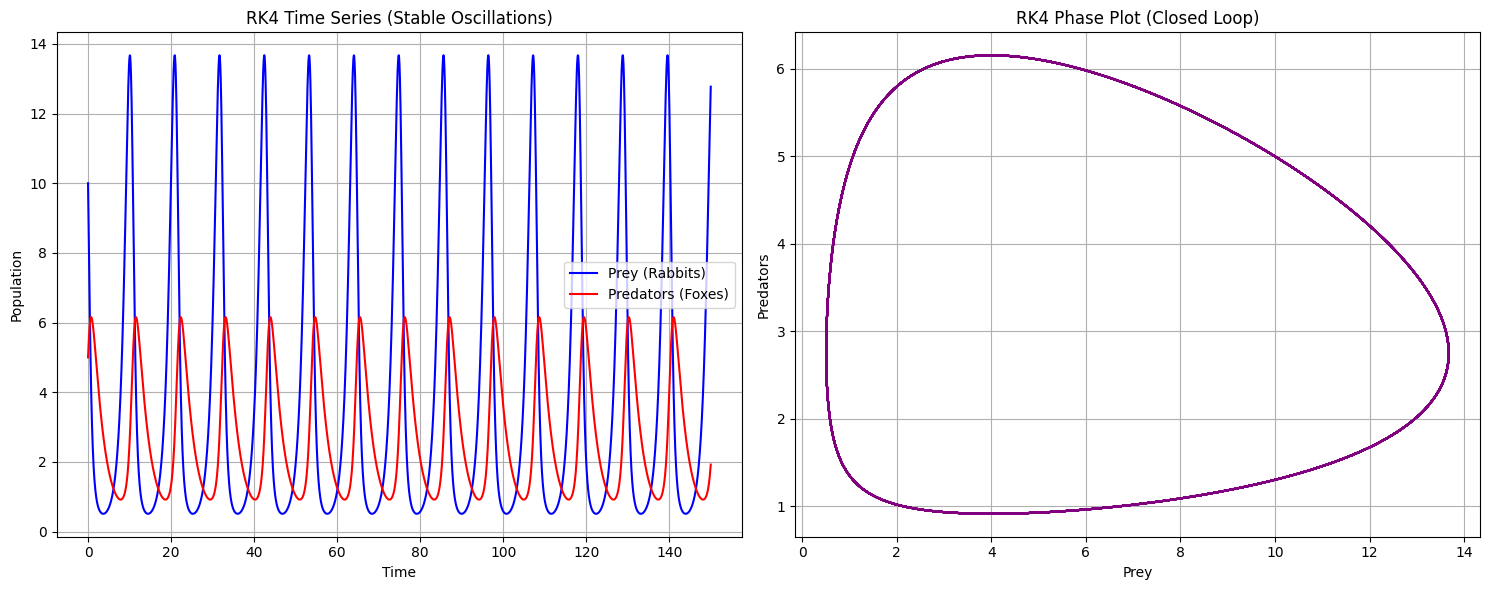

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Differential Equations (No Carrying Capacity)
def system_dynamics(z, a, b, c, d):
    x, y = z
    dxdt = a * x - b * x * y
    dydt = d * x * y - c * y
    return np.array([dxdt, dydt])

# 2. Parameters (Matching the clean oscillations in your image)
a, b, c, d = 1.1, 0.4, 0.4, 0.1
dt = 0.05       # RK4 is stable enough for a larger dt than Euler
t_final = 150
steps = int(t_final / dt)

# 3. Initialize storage
results = np.zeros((steps, 2))
t = np.linspace(0, t_final, steps)
z = np.array([10.0, 5.0]) # Initial populations: [Prey, Predator]

# 4. The RK4 Simulation Loop
for i in range(steps):
    results[i] = z
    
    # Calculate the 4 trial slopes (k values)
    k1 = system_dynamics(z, a, b, c, d)
    k2 = system_dynamics(z + (dt/2)*k1, a, b, c, d)
    k3 = system_dynamics(z + (dt/2)*k2, a, b, c, d)
    k4 = system_dynamics(z + dt*k3, a, b, c, d)
    
    # Update state using weighted average: (k1 + 2k2 + 2k3 + k4) / 6
    z = z + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

# Split results for plotting
prey, predators = results.T

# 5. Visualization: Time Series and Phase Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Time Series
ax1.plot(t, prey, label='Prey (Rabbits)', color='blue')
ax1.plot(t, predators, label='Predators (Foxes)', color='red')
ax1.set_title('RK4 Time Series (Stable Oscillations)')
ax1.set_xlabel('Time')
ax1.set_ylabel('Population')
ax1.legend()

- source if the divergence  THere could be orthogonal fffffffffffffffffff
ax1.grid(True)

# Phase Plot
ax2.plot(prey, predators, color='purple')
ax2.set_title('RK4 Phase Plot (Closed Loop)')
ax2.set_xlabel('Prey')
ax2.set_ylabel('Predators')
ax2.grid(True)

plt.tight_layout()
plt.show()

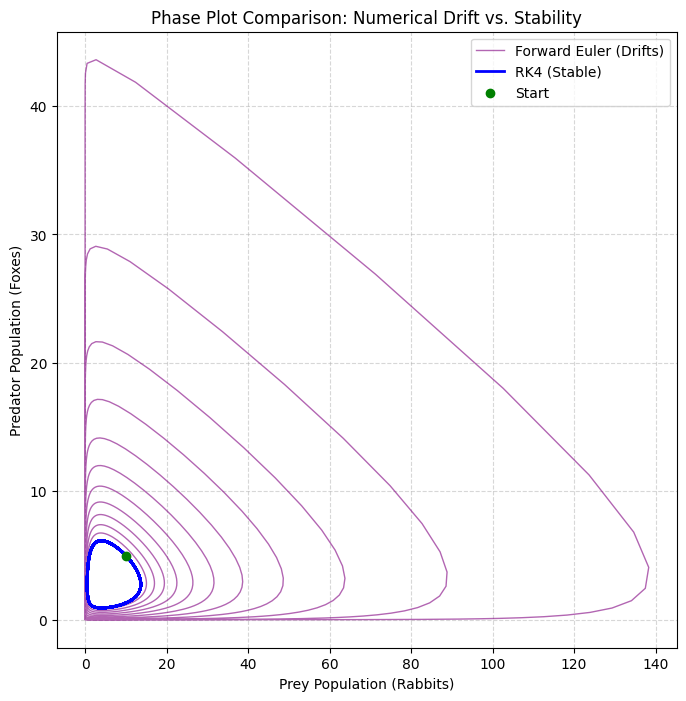

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Model Parameters
a, b, c, d = 1.1, 0.4, 0.4, 0.1
dt = 0.05  
t_final = 200
steps = int(t_final / dt)

# Define the derivative function
def f(z):
    x, y = z
    return np.array([a*x - b*x*y, d*x*y - c*y])

# 2. Storage for both methods
z_rk4 = np.zeros((steps, 2))
z_euler = np.zeros((steps, 2))

# Initial Conditions
z_rk4[0] = [10.0, 5.0]
z_euler[0] = [10.0, 5.0]

# 3. Simulation Loop
for i in range(1, steps):
    # --- RK4 Method ---
    state_rk4 = z_rk4[i-1]
    k1 = f(state_rk4)
    k2 = f(state_rk4 + (dt/2)*k1)
    k3 = f(state_rk4 + (dt/2)*k2)
    k4 = f(state_rk4 + dt*k3)
    z_rk4[i] = state_rk4 + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)
    
    # --- Forward Euler Method ---
    state_euler = z_euler[i-1]
    z_euler[i] = state_euler + f(state_euler) * dt

# 4. Plotting the Comparison
plt.figure(figsize=(8, 8))

# Plot Euler (The Drifting Spiral)
plt.plot(z_euler[:, 0], z_euler[:, 1], color='purple', lw=1, alpha=0.6, label='Forward Euler (Drifts)')

# Plot RK4 (The Stable Loop)
plt.plot(z_rk4[:, 0], z_rk4[:, 1], color='blue', lw=2, label='RK4 (Stable)')

# Visual markers
plt.scatter(10, 5, color='green', zorder=5, label='Start')
plt.title('Phase Plot Comparison: Numerical Drift vs. Stability')
plt.xlabel('Prey Population (Rabbits)')
plt.ylabel('Predator Population (Foxes)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()